In [2]:
## IMPORTANT: On Colab, we expect your homework files (requirements.txt and this notebook)
## to be in the comp351/hw/hw0 folder in your Google Drive.

## Please contact us if you encounter any problems with installing dependencies
import sys
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/comp351/hw/hw0/code
    %pip install -r ./requirements.txt
    !pip install -U kaleido plotly
    import kaleido
    kaleido.get_chrome_sync()

import plotly.io as pio
pio.renderers.default = pio.renderers.default + "+png"


Mounted at /content/drive
/content/drive/MyDrive/comp351/hw/hw0/code
  Cloning https://github.com/BerkeleyML/otter-grader-189.git (to revision master) to /tmp/pip-install-x3kq3wzu/otter-grader_491d21cd7ac14cd68ed8cd83829bf45d
  Running command git clone --filter=blob:none --quiet https://github.com/BerkeleyML/otter-grader-189.git /tmp/pip-install-x3kq3wzu/otter-grader_491d21cd7ac14cd68ed8cd83829bf45d
  Resolved https://github.com/BerkeleyML/otter-grader-189.git to commit 35e43fdf64a55f4b9222d7b531890fb7d5cb498c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Initialize Otter
import otter
grader = otter.Notebook("fashion_pt_1.ipynb")

<link rel="stylesheet" href="berkeley.css">

<h1 class="cal cal-h1">Homework 0.1 – AGI, Everywhere, All at Once</h1>

Welcome to Homework 0.1! In this assignment, you will get familiar with common data and visualization tools like `numpy`, `pandas`, and `plotly`. This notebook emphasizes `pandas` operations throughout, and you will work with `DataFrames` as your primary data structure.

---

## Due Date: Sunday, March 1, 11:59 PM

This assignment is due on **Sunday, March 1, at 11:59 PM**. You must submit your work to LearnHub by this deadline.

### Submission Tips:
- **Plan ahead**: We strongly encourage you to submit your work several hours before the deadline. This will give you ample time to address any submission issues.
- **Reach out for help early**: If you encounter difficulties, contact course staff well before the deadline. While we are happy to assist with submission issues, we cannot guarantee responses to last-minute requests.

---

## Assignment Overview

This notebook contains a series of tasks designed to help you practice and apply key concepts in data manipulation and visualization. You will complete all the TODOs in the notebook, which include both coding and written response questions. Some tasks are open-ended, which allows you to explore and experiment with different approaches.

### Key Learning Objectives:
1. Work with `numpy` and `pandas` for data manipulation.
2. Visualize data using `plotly` and `pandas`' built-in plotting functions.
3. Gain experience with organizing and analyzing datasets.
4. Understand the importance of data exploration and preprocessing.

---

### Instructions:
1. Carefully read each question and its requirements.
2. Complete all TODOs in the notebook. You may add extra lines of code if needed to implement your solution.
3. For manual questions, provide clear and concise written responses.
4. Test your code thoroughly to ensure it meets the requirements.

Good luck!

In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import torchvision
import os
import random
from IPython.display import display

### **IMPORTANT:**
- Do not change the random seed values!!!
- Before you submit your notebook, remember to set `save_models=True` and `load_models=True`. This saves your final models which we will use for the autograder. Set these to false if you are still tweaking your model setup. We have provided code for saving models - **do not change these file names!!**
- When uploading your notebook, make sure to include your model file `classifier.joblib` in your submission

In [5]:
# Set random seeds for reproducible results
SEED = 189
np.random.seed(SEED)
random.seed(SEED)

# IMPORTANT: set save_models to True to save trained models. YOU NEED TO DO THIS FOR THE AUTOGRADER TO WORK.
import joblib
save_models = True
load_saved_models = True # After training, you can set this to True to load the saved models and not have to re-train them.

<link rel="stylesheet" href="berkeley.css">

## Setup

### Load the Fashion-MNIST dataset  

In this homework, we will work with the Fashion-MNIST dataset, a widely used benchmark dataset for machine learning. It consists of grayscale 28x28 pixel images of various articles of clothing, making it an excellent dataset for practicing image classification.

>[Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms.](https://arxiv.org/abs/1708.07747) Han Xiao, Kashif Rasul, Roland Vollgraf.
> https://github.com/zalandoresearch/fashion-mnist

This dataset serves as an alternative to the classic MNIST digits dataset, which contains images of handwritten digits. Fashion-MNIST is more challenging and better reflects real-world image classification tasks.

We will load the dataset using [torchvision](https://docs.pytorch.org/vision/stable/index.html), a PyTorch library that provides popular datasets, models, and transformation tools. While you don't need to fully understand PyTorch for this homework, it's helpful to know that the dataset contains two key components:
* `data`: the images themselves, represented as 28x28 grayscale arrays.
* `targets`: the class labels for each image, where each label corresponds to a specific article of clothing.

The dataset includes 10 classes, each representing a type of clothing item:
- `T-shirt/top`
- `Trouser`
- `Pullover`
- `Dress`
- `Coat`
- `Sandal`
- `Shirt`
- `Sneaker`
- `Bag`
- `Ankle boot`

We will explore this dataset in detail and use it to practice data manipulation, visualization, and machine learning techniques.

In [6]:
# Load the FashionMNIST dataset from torchvision
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)

# Extract the image data and convert it to a numpy array of type float
images = train_data.data.numpy().astype(float)

# Extract the target labels as a numpy array
targets = train_data.targets.numpy()

# Create a dictionary mapping class indices to class names
class_dict = {i: class_name for i, class_name in enumerate(train_data.classes)}

# Map the target labels to their corresponding class names
labels = np.array([class_dict[t] for t in targets])

# Create a list of class names in order of their indices
class_names = [class_dict[i] for i in range(len(class_dict))]

# Get the total number of samples in the dataset
n = len(images)

# Ensure class_names is a list of class names (redundant but ensures consistency)
class_names = list(class_dict.values())

# Print dataset information for verification
print("Loaded FashionMNIST dataset with {} samples.".format(n))
print("Classes: {}".format(class_dict))
print("Image shape: {}".format(images[0].shape))  # Shape of a single image
print("Image dtype: {}".format(images[0].dtype))  # Data type of the image array
print("Image type: {}".format(type(images[0])))   # Type of the image object

Loaded FashionMNIST dataset with 60000 samples.
Classes: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
Image shape: (28, 28)
Image dtype: float64
Image type: <class 'numpy.ndarray'>


**Now let's create a `DataFrame` to organize our data**

In this class, we will be using a lot of [pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html), which is a powerful library for data analysis and manipulation. A `DataFrame` in pandas is essentially a table where we can store and perform operations on our data.

### Why use a `DataFrame`?

A `DataFrame` allows us to:
- Organize data into rows and columns for better readability.
- Perform efficient operations on the data, such as filtering, grouping, and aggregating.
- Integrate seamlessly with other libraries for visualization and machine learning.

### Problem 0a

**Task:** Create a `DataFrame` called `df` with two columns: `image` and `label`. Each row should correspond to an image and its associated label. You can preview the first 5 rows of a `DataFrame` by calling `df.head()`.

**Hints:**
1. What is the current object type of the variable `images`? Note that `pandas` expects 1D or 2D data for each value in a `DataFrame` column. You may need to first convert `images` to a Python list before using it to create the `DataFrame`.
2. Later on, when we use our `DataFrame` for training, it's best if the values in the `image` column are [`ndarray`](https://numpy.org/doc/stable/reference/arrays.ndarray.html) objects. After creating the `DataFrame`, consider re-casting all the values in the `image` column to `ndarray` for consistency.

In [7]:
# TODO: Create a DataFrame with two columns: `image` and `label`

df = pd.DataFrame({"image": images.tolist(), "label": labels})
df["image"] = df["image"].apply(np.array)

# Print the shape and columns of the DataFrame
print("DataFrame shape:", df.shape)
print("DataFrame columns:", df.columns.tolist())
df.head()

DataFrame shape: (60000, 2)
DataFrame columns: ['image', 'label']


,image,label
0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",Ankle boot
1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",T-shirt/top
2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",T-shirt/top
3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 33.0...",Dress
4,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",T-shirt/top


In [8]:
grader.check("q0")

q0 results: All test cases passed!

## Problem 1: Introduction to `pandas` and `Plotly`

Now that we have created our `DataFrame`, let's start analyzing our data. A key aspect of machine learning is understanding the data you are working with, so let's create some visualizations of our dataset.

One of the first steps in data analysis is to check how "balanced" the dataset is. This means examining the distribution of the labels to see if each class appears equally in the dataset. A balanced dataset ensures that no class is overrepresented or underrepresented, which can impact the performance of machine learning models.

### Problem 1a: Checking Dataset Balance

**Task**: Calculate the distribution of the `label` column in the `df` `DataFrame` using [`value_counts()`](https://pandas.pydata.org/pandas-docs/version/2.1.2/reference/api/pandas.Series.value_counts.html) and store it in a variable called `label_distribution`. Then, determine whether or not our dataset is balanced by comparing the minimum and maximum values of `label_distribution`. Store the result as a boolean value in the `is_balanced` variable.

In [9]:
# TODO: Calculate the distribution of labels using `value_counts()``
# TODO: Compare the min and max values of `label_distribution` to determine if the dataset is balanced.

label_distribution = df["label"].value_counts()
is_balanced = label_distribution.min() == label_distribution.max()

print(f"Label distribution:\n{label_distribution}")
print(f"Is the dataset balanced? {is_balanced}")

Label distribution:
label
Ankle boot     6000
T-shirt/top    6000
Dress          6000
Pullover       6000
Sneaker        6000
Sandal         6000
Trouser        6000
Shirt          6000
Coat           6000
Bag            6000
Name: count, dtype: int64
Is the dataset balanced? True


In [10]:
grader.check("q1a")

q1a results: All test cases passed!

### Problem 1b: Grouping Data with `groupby()`

The `groupby()` function in `pandas` is a powerful tool for grouping rows based on column values and applying aggregation functions like `.size()`.

**Task:**
Group `df` by the `label` column and count the rows in each group using `.size()`.

#### Example Output:

| label        | count |
|--------------|-------|
| Ankle boot   | 6000  |
| Bag          | 6000  |
| ...          | ...   |

[Learn more about `groupby()` here.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)


In [11]:
# TODO: Group the rows in `df` according to the values in the `labels` column. Then, count the number of rows in each group.
label_distribution_groupby = df.groupby("label").size()

In [12]:
grader.check("q1b")

q1b results: All test cases passed!

### Problem 1c: Visualizing Label Distribution

One of the strengths of `pandas` is its ability to quickly generate visualizations of data. This is particularly useful for understanding the distribution of your dataset. In this task, we will use `pandas`' built-in plotting functions to create a visualization of the label distribution in our `DataFrame`.

#### Why Visualize Label Distribution?

Visualizing the label distribution helps us:
- Understand the balance of classes in the dataset.
- Identify any potential biases or imbalances that could affect model performance.
- Gain insights into the dataset before proceeding with further analysis.

**Task:**
1. Use the `pandas` [built-in plotting functions](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) to create a histogram of the label distribution. (x-axis is the class label and y axis is the sample count)
2. Ensure the chart is clear and labeled appropriately for easy interpretation.

In [13]:
# Plotting library to use, default is matplotlib but plotly has more functionality
pd.options.plotting.backend = "plotly"

# TODO: Plot a histogram of the labels in the DataFrame `df` using the DataFrame's built-in plotting functions (this should be 1 line)
df["label"].plot(kind="hist", x="label")

BrowserDepsError: It seems like you are running a slim version of your operating system and are missing some common dependencies. The following command should install the required dependencies on most systems:

$ sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

If you have already run the above command and are still seeing this error, or the above command fails, consult the Kaleido documentation for operating system to install chromium dependencies.

For support, run the command `choreo_diagnose` and create an issue with its output.

BrowserDepsError: It seems like you are running a slim version of your operating system and are missing some common dependencies. The following command should install the required dependencies on most systems:

$ sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

If you have already run the above command and are still seeing this error, or the above command fails, consult the Kaleido documentation for operating system to install chromium dependencies.

For support, run the command `choreo_diagnose` and create an issue with its output.

BrowserDepsError: It seems like you are running a slim version of your operating system and are missing some common dependencies. The following command should install the required dependencies on most systems:

$ sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2

If you have already run the above command and are still seeing this error, or the above command fails, consult the Kaleido documentation for operating system to install chromium dependencies.

For support, run the command `choreo_diagnose` and create an issue with its output.

Figure({
    'data': [{'bingroup': 'x',
              'hovertemplate': 'label=%{x}<br>count=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'histogram',
              'x': array(['Ankle boot', 'T-shirt/top', 'T-shirt/top', ..., 'Dress', 'T-shirt/top',
                          'Sandal'], dtype=object),
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'barmode': 'relative',
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'label'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'count'}}}
})

Here is the `show_images` function. This function visualizes our images and labels each of them with what class they are from.

In [14]:
def show_images(images, max_images=40, ncols=5, labels = None, reshape=False):
    """Visualize a subset of images from the dataset.
    Args:
        images (np.ndarray or list): Array of images to visualize [img,row,col].
        max_images (int): Maximum number of images to display.
        ncols (int): Number of columns in the grid.
        labels (np.ndarray, optional): Labels for the images, used for facet titles.
    Returns:
        plotly.graph_objects.Figure: A Plotly figure object containing the images.
    """
    if isinstance(images, list):
        images = np.stack(images)
    n = min(images.shape[0], max_images) # Number of images to show
    px_height = 220 # Height of each image in pixels
    if reshape:
        images = images.reshape(images.shape[0], 28, 28)
    fig = px.imshow(images[:n, :, :], color_continuous_scale='gray_r',
                    facet_col = 0, facet_col_wrap=ncols,
                    height = px_height * int(np.ceil(n/ncols)))
    fig.update_layout(coloraxis_showscale=False)
    fig.update_xaxes(showticklabels=False, showgrid=False)
    fig.update_yaxes(showticklabels=False, showgrid=False)
    if labels is not None:
        # Extract the facet number and replace with the label.
        fig.for_each_annotation(lambda a: a.update(text=labels[int(a.text.split("=")[-1])]))
    return fig

### Problem 1d: Visualizing Class Examples

To better understand the dataset, let's visualize a few examples from each class. This will help us see what the images look like and how they differ across classes.

**Task**:
1. Use the `pandas` `groupby` function to group the `DataFrame` by the `label` column.
2. Sample 2 images per class.
3. Use the `show_images` function to display the images in a grid, with each image labeled by its class name.

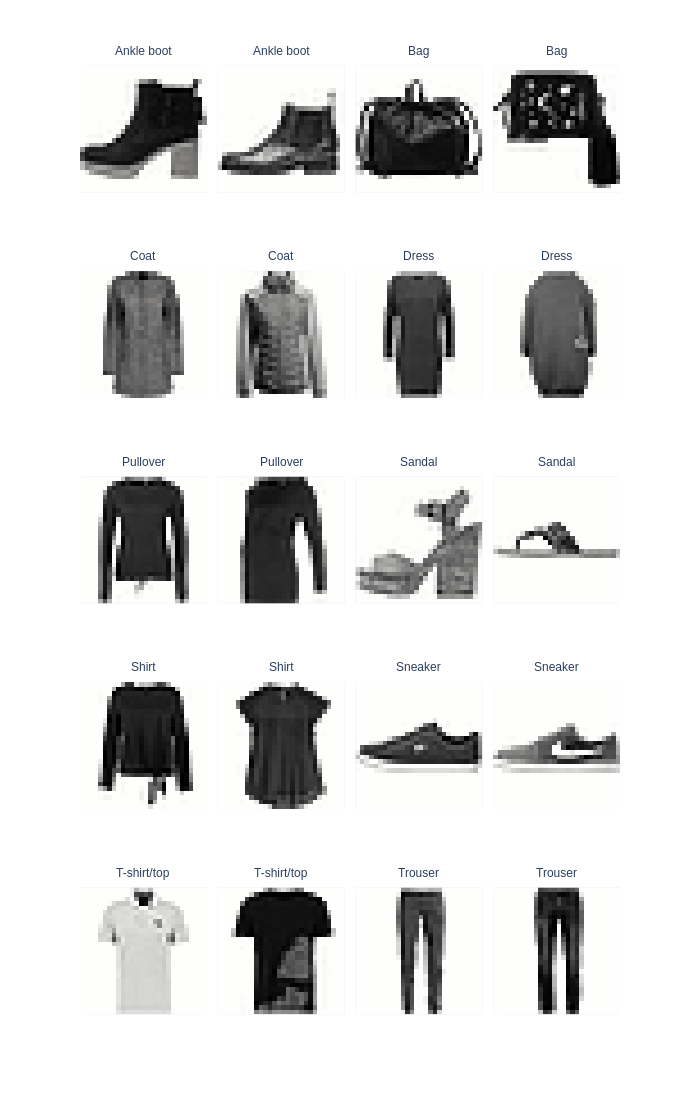

In [17]:
# TODO: Get 2 sample images per class and plot them.
examples = df.groupby("label").sample(2)

fig = show_images(examples["image"].tolist(), ncols=4, labels=examples["label"].tolist())
fig.show()

In [18]:
grader.check("q1d")

q1d results: All test cases passed!

## Problem 2: Understanding Data Structure with Clustering

Before training classifiers, we explore the data structure using **k-means clustering**, an unsupervised learning method. This helps identify patterns and relationships in the dataset.

**Why Clustering?**

- **Discover Similarities**: Group similar clothing items based on pixel values.
- **Data Insights**: Understand dataset structure to guide modeling.
- **Simplify Data**: Potential preprocessing or dimensionality reduction.

**Steps:**
1. Flatten images for clustering (done below).
2. Apply k-means to group images.
3. Analyze clusters for patterns.

Before we can apply clustering algorithms or train models, we need to preprocess our images. Most machine learning algorithms expect input data to be in a 1-dimensional format. Currently, our images are in a 2D format with dimensions `(28, 28)`.

Thus, let's first reshape each image from `(28, 28)` to a 1-dimensional array of size `(784,)` using the Pandas the [`apply()`](https://pandas.pydata.org/pandas-docs/version/2.1.2/reference/api/pandas.DataFrame.apply.html) function

In [19]:
df["image"] = df["image"].apply(lambda img: img.reshape(-1))
np.stack(df['image'].values).shape

(60000, 784)

### Problem 2a: K-means Clustering on the Pixels

Use K-means clustering to group similar images based on their pixel values. This will help us understand how well the algorithm can identify patterns in the dataset without using the labels.

**Task**:
1. Use the [sklearn's `KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) class to cluster the images into `10` clusters (since there are 10 classes in the dataset). For efficiency we will only cluster a 1000 image sample (`df_sample`).
2. Create a `DataFrame` called `kmeans_df` with the following columns:
    - `image`: the image data (flattened to 1D arrays of size 784).
    - `label`: the true class label of the image.
    - `cluster`: the cluster label assigned by K-means.

**Instructions**:
- When clustering, set `random_state=SEED` for reproducibility.

**Expected Output**:
The `kmeans_df` DataFrame should look like this:

| cluster | label       | image                                   |
|---------|-------------|-----------------------------------------|
| 7       | Ankle boot  | [0.0, 0.0, 0.0, 0.0, 0.0, ...]         |
| 6       | T-shirt/top | [0.0, 0.0, 0.0, 0.0, 1.0, ...]         |

In [20]:
# TODO: Perform k-means clustering on the images (10 clusters to match the number of classes)
from sklearn.cluster import KMeans

df_sample = df.sample(n=1000, random_state=SEED)
kmeans = KMeans(n_clusters=10, random_state=SEED).fit_predict(np.stack(df_sample["image"]))

kmeans_df = df_sample.copy()
kmeans_df["cluster"] = kmeans

kmeans_df.head(3)

,image,label,cluster
15248,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Bag,1
47407,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 54.0,...",T-shirt/top,1
44790,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Trouser,2


In [21]:
grader.check("q2a")

q2a results: All test cases passed!

### Problem 2b: Evaluating K-means Clustering

K-means clustering groups data points into clusters based on their similarity. To evaluate how well the clustering algorithm has separated the classes, we can analyze the distribution of true labels within each cluster.

**Task:**
1. Use the `kmeans_df` `DataFrame` to calculate the distribution of true labels (`label`) within each cluster (`cluster`).
2. Create a [stacked bar plot](https://plotly.com/python/bar-charts/) to visualize the label counts per cluster. Each bar should represent a cluster, and the segments of the bar should represent the counts of each label within that cluster.

**Hint:** If you are running into issues where there are bars “hidden” behind other ones in your Plotly bar chart, try making sure you use fillna(0) or unstack(fill_value=0) after grouping by your KMean clusters.

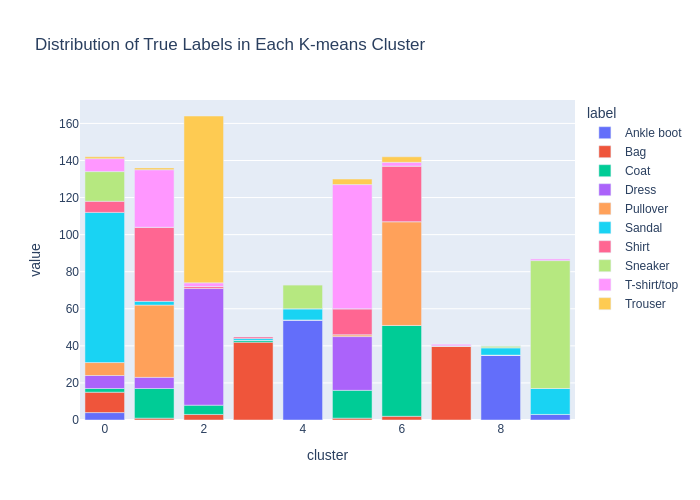

In [22]:
# TODO: Create a stacked bar plot of the label counts per cluster.
cluster_label_counts = kmeans_df.groupby(["cluster", "label"]).size().unstack(fill_value=0)

cluster_label_counts.plot(
    kind='bar',
    title='Distribution of True Labels in Each K-means Cluster'
)

### Problem 2c: Visualizing Clusters

To better understand the clusters formed by the K-means algorithm, we will visualize a few sample images from each cluster. This will help us identify patterns or similarities among images within the same cluster.

**Task:**
1. For each cluster, randomly sample 7 images.
2. Use the `show_images` function to display the sampled images in a grid.
3. Observe the visual similarities among images in the same cluster.

<!-- BEGIN QUESTION -->



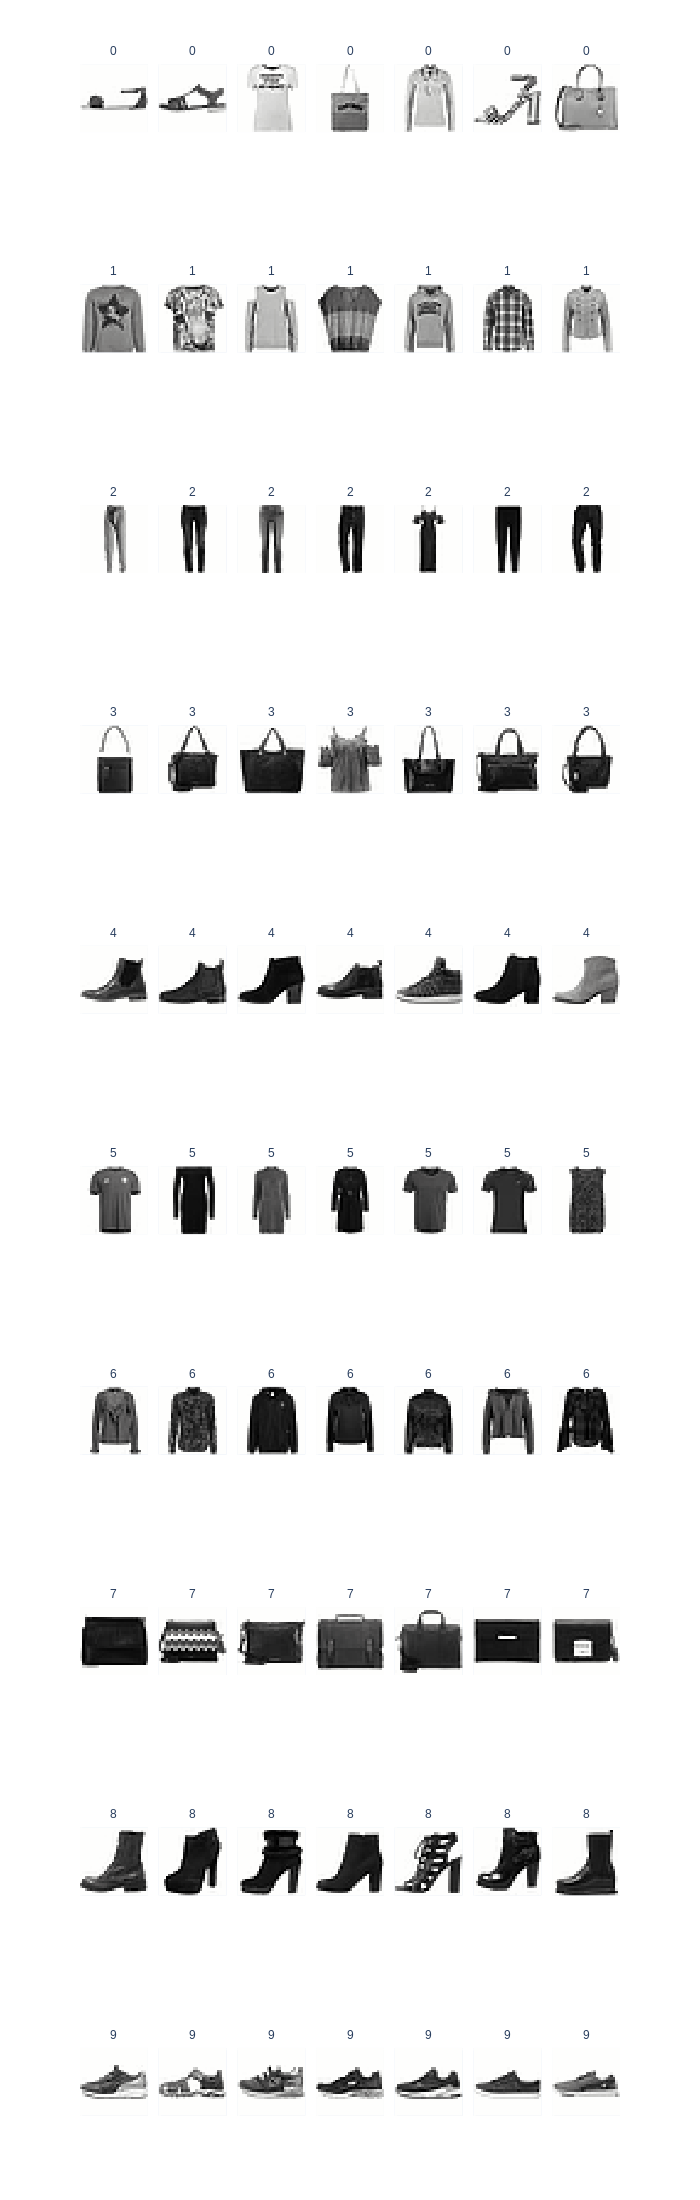

In [23]:
# TODO: Plot 7 images from each cluster (use the show_images function, 10 rows, 7 columns)
kmeans_df["image"] = kmeans_df["image"].apply(lambda img: img.reshape(28, 28))
examples = kmeans_df.groupby("cluster").sample(7)

fig = show_images(examples["image"].tolist(), max_images=70, ncols=7, labels=examples["cluster"].tolist())
fig.show()

<!-- END QUESTION -->

### Problem 2d: Observing Patterns in K-means Clustering

Reflecting on the visualizations from the previous part, we observe that the k-means clustering algorithm groups images not only by their clothing category (class) but also by other shared characteristics.

**Question:** Besides the clothing category, what other visual or structural characteristics of the images might the k-means clustering algorithm be grouping together?

_Color, shape, the areas they cover._

<!-- END QUESTION -->

## Problem 3: Training a Classifier

In this section, we will train a machine learning classifier to predict clothing categories from image pixel data. Specifically, we will use a Multi-Layer Perceptron (MLP) classifier, which is a type of neural network.

### Workflow Overview

We will follow a structured workflow:
1. **Data Preparation**: Split the dataset into training and testing sets while maintaining class balance.
2. **Model Training**: Train the MLP classifier on the training set.
3. **Model Evaluation**: Evaluate the classifier's performance on the test set using metrics like accuracy.
4. **Visualization**: Visualize predictions and analyze misclassifications to understand model behavior.

This workflow mirrors the process used in the lecture notebook, but you will implement some of the functions yourself to deepen your understanding.

**Creating Train/Test Split** As mentioned in lecture, first we will split our dataset into training and testing sets. This is a crucial step in machine learning to evaluate how well a model generalizes to unseen data.

Unlike the lecture, where we used sklearn's [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function, we have split our dataset using pandas functions.

**Do not change this function!** Otherwise the autograder will likely fail.

In [24]:
df_copy = df.copy()
train_df = df_copy.groupby('label').sample(frac=0.8, random_state=SEED)
test_df = df_copy[~df_copy.index.isin(train_df.index)]
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 48000
Test set size: 12000


### Problem 3a: Train MLP Classifier

In this task, we will train a Multi-Layer Perceptron (MLP) classifier to predict clothing categories from image data. The MLP is a type of neural network that is well-suited for classification tasks. The demo notebook from lecture 3 (https://eecs189.org/fa25/lecture/lec03/) could be particularly useful.  

**Steps to Follow:**

1. **Data Normalization**:
    - Scale the pixel values of the images to the range `[0, 1]` for better training performance.
    - Create new variables `X_train_sc` and `X_test_sc` for the scaled training and testing data, respectively. Do not overwrite the original `X_train` and `X_test`.

2. **Model Training**:
    - Use the same MLP configuration (size, hyperparameters) as demonstrated in the lecture 3 notebook.
    - Train the model on the normalized training data.

3. **Loss Curve**:
    - Extract the loss curve from the trained model using the `model.loss_curve_` attribute.
    - Create a `DataFrame` called `loss_df` with two columns: `epoch` and `loss`.
    - Use Plotly Express to plot the loss curve, showing how the loss decreases as the number of epochs increases.


**Notes:**
- The term "loss" refers to the error (textbook terminology) during training. Minimizing the loss is the goal of the training process.
- Ensure that the model is trained with reproducibility in mind (e.g., set a random seed to `SEED` where applicable).

In [25]:
# Importing necessary modules for training and preprocessing
from sklearn.neural_network import MLPClassifier  # Multi-Layer Perceptron Classifier for training
from sklearn.preprocessing import StandardScaler  # StandardScaler for normalizing the data

X_train shape: (48000, 784)	 y_train shape: (48000,)
X_test shape: (12000, 784)	 y_test shape: (12000,)
Loaded model with accuracy: 0.885


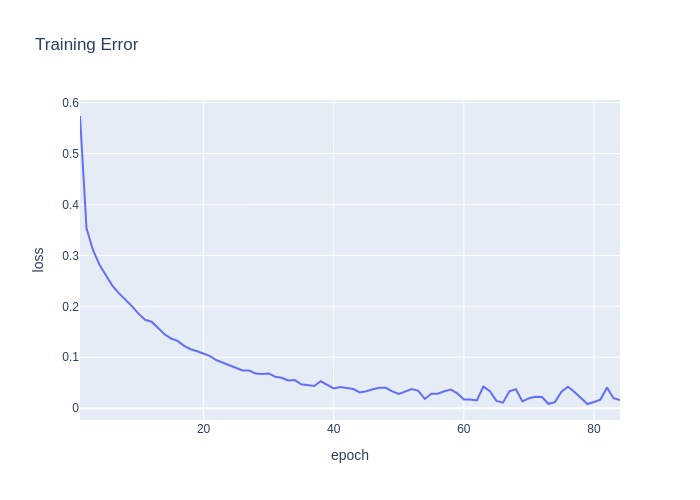

In [26]:
# flatten features into 1D arrays
X_train = np.stack(train_df['image'].values)
y_train = train_df['label'].values
X_test = np.stack(test_df['image'].values)
y_test = test_df['label'].values

print(f"X_train shape: {X_train.shape}\t y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}\t y_test shape: {y_test.shape}")

# TODO: Train the model using the scaled traning data and plott the loss curve (remeber to normalize your data!)
# NOTE: Your model must be named `model`

x_tr_scaler = StandardScaler();
x_tr_scaler.fit(X_train)
X_train_sc = x_tr_scaler.transform(X_train)

x_te_scaler = StandardScaler();
x_te_scaler.fit(X_test)
X_test_sc = x_te_scaler.transform(X_test)

if load_saved_models and os.path.exists('classifier.joblib'):
    model = joblib.load('classifier.joblib')
    acc = model.score(X_test_sc, y_test)
    print(f"Loaded model with accuracy: {acc}")
else:
    model = MLPClassifier(hidden_layer_sizes=(100, 50),
                          max_iter=100, tol=1e-3, random_state=SEED)
    model.fit(X_train_sc, y_train)
    acc = model.score(X_test_sc, y_test)
    print(f"Trained model with accuracy: {acc}")
if save_models:
    joblib.dump(model, 'classifier.joblib')

loss_df = pd.DataFrame({
    'epoch': range(1, len(model.loss_curve_) + 1),
    'loss': model.loss_curve_
})

loss_df.plot(x='epoch', y='loss', title="Training Error")

In [27]:
grader.check("q3a")

q3a results: All test cases passed!

### Problem 3b: Adding Predictions and Evaluation Metrics to DataFrames

**Task:** Modify both `train_df` and `test_df` by adding the following columns and compute train and test accuracy:

1. **`predicted_label`**: The predicted label for each image, as determined by the trained model.
2. **`correct`**: A boolean value indicating whether the predicted label matches the true label (`True` for correct predictions, `False` otherwise).
3. **`probs`**: The class probabilities for each image, represented as a list of size 10 (one probability per class).
4. **`confidence`**: The probability associated with the predicted label, representing the model's confidence in its prediction.

In [28]:
# TODO: Add the columns listed above to `train_df` and `test_df`.
train_df = train_df.copy()
test_df = test_df.copy()

train_df['predicted_label'] = model.predict(X_train_sc)
train_df['correct'] = train_df['predicted_label']==y_train
train_df['probs'] = model.predict_proba(X_train_sc).tolist()
train_df['confidence'] = train_df['probs'].apply(lambda x: max(x))

test_df['predicted_label'] = model.predict(X_test_sc)
test_df['correct'] = test_df['predicted_label']==y_test
test_df['probs'] = model.predict_proba(X_test_sc).tolist()
test_df['confidence'] = test_df['probs'].apply(lambda x: max(x))


print("--- Column Types ----")
for col in train_df.columns:
    val = train_df[col].iloc[0]
    print(f"{col}: {type(val)}")
print("-----------")

train_accuracy = train_df['correct'].sum()/len(train_df['correct'])
test_accuracy = test_df['correct'].sum()/len(test_df['correct'])

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

--- Column Types ----
image: <class 'numpy.ndarray'>
label: <class 'str'>
predicted_label: <class 'str'>
correct: <class 'numpy.bool'>
probs: <class 'list'>
confidence: <class 'numpy.float64'>
-----------
Training accuracy: 0.995
Test accuracy: 0.885


In [29]:
grader.check("q3b")

q3b results: All test cases passed!

### Problem 3c: Class Accuracy Analysis and Visualization

Analyze the model's performance for each class and visualize the class-wise accuracy for both the training and testing datasets.

#### **Task 1**: Create a `class_accuracy` DataFrame
1. Group the `train_df` and `test_df` DataFrames by `label` (class).
2. Calculate the accuracy for each class as the proportion of correct predictions (`correct` column).
3. Add a `split` column to indicate whether the data is from the training or testing set.
4. Combine the results into a single DataFrame called `class_accuracy` with the following columns:
    - `split`: Indicates whether the data is from the training or testing set.
    - `label`: The class label.
    - `correct`: The accuracy for the class.


#### **Task 2**: Visualize Class Accuracy
1. Use the `class_accuracy` DataFrame to create a grouped bar chart.
2. The x-axis should represent the class labels (`label`), and the y-axis should represent the accuracy (`correct`).
3. Use different colors for the training and testing splits:
    - Training: Blue
    - Testing: Red
4. Add the actual accuracy values on top of the bars, rounded to two decimal places. To do this you can add `text_auto=True` to your `.plot` call. If you want to round these numbers to the nearest 2nd decimal, set `text_auto='.2f'`


**Hints**:
- Use `reset_index()` after grouping to convert the grouped data into a DataFrame.

For example, after a groupby:

    df.groupby(['A', 'B'])['C'].mean()

you get a Series with a multi-index:

```bash
    A      B       
    foo    x      0.92
           y      0.85
    bar    x      0.99
           y      0.97
    Name: C, dtype: float64
```

If you call `.reset_index()`, you get a `DataFrame` with columns:

```bash
       A    B     C
    0  foo  x  0.92
    1  foo  y  0.85
    2  bar  x  0.99
    3  bar  y  0.97
```

This makes it much easier to plot or further manipulate the data.

          label   correct  split
0    Ankle boot  0.998125  train
1           Bag  1.000000  train
2          Coat  0.987917  train
3         Dress  0.997083  train
4      Pullover  0.990417  train
5        Sandal  0.998542  train
6         Shirt  0.990417  train
7       Sneaker  1.000000  train
8   T-shirt/top  0.990208  train
9       Trouser  1.000000  train
10   Ankle boot  0.950000   test
11          Bag  0.962500   test
12         Coat  0.820000   test
13        Dress  0.895000   test
14     Pullover  0.807500   test
15       Sandal  0.948333   test
16        Shirt  0.712500   test
17      Sneaker  0.955000   test
18  T-shirt/top  0.820833   test
19      Trouser  0.978333   test


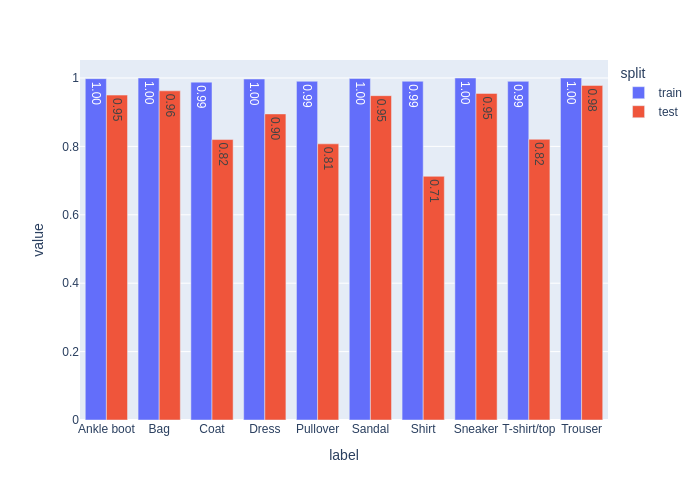

In [45]:
# TODO: Calculate train and test accuracy per class
# TODO: Use class_accuracy to create a grouped bar chart of class accuracy for train and test

train_df_grouped = train_df.groupby("label")
tr_class_accuracy = train_df_grouped['correct'].mean().reset_index()
tr_class_accuracy['split'] = 'train'
test_df_grouped = test_df.groupby("label")
te_class_accuracy = test_df_grouped['correct'].mean().reset_index()
te_class_accuracy['split'] = 'test'

class_accuracy = pd.concat([tr_class_accuracy, te_class_accuracy]).reset_index(drop=True)

print(class_accuracy)
class_accuracy.pivot(index='label', columns='split', values='correct')[['train', 'test']].plot(kind='bar', barmode='group', text_auto='.2f')

In [46]:
grader.check("q3c")

q3c results: All test cases passed!

### Problem 3d: Best and Worst Performing Classes

**Question:**  
- Identify the best and worst performing classes for train and test splits. If tied, list all classes with the same performance.  
- Do the best/worst performing classes match between splits?  
- Do train and test accuracies differ? Why?


_Train Best(s): Bag, Sneaker, Trouser_

_Test Best: Trouser_

_Train Worst: Coat_

_Test Worst: Shirt_

Trouser is the best for both train and test but the worst doesn't match.

Train accuracies are obviously better since the model saw these data during training but test data hasn't been seen yet.

<!-- END QUESTION -->

### Problem 3e: Create Confusion Matrix

An often easier way to understand model performance is with a confuction matrix, which show how often predictions match the true labels and where errors occur.

---

#### Refresher:
1. **Precision**: Measures the accuracy of positive predictions for a class.
  $$
  \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
  $$

2. **Recall**: Measures the ability to identify all positive samples for a class.
  $$
  \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
  $$

---

**Tasks**:
1. **Hand-implement a confusion matrix**:
  - Use numpy operations to compute a 10x10 matrix where rows represent true labels and columns represent predicted labels.
  
2. **Visualize the confusion matrix**:
  - Use a [heatmap](https://plotly.com/python/heatmaps/) to display the matrix for better interpretability. Y axis should be the true label and the X axis should be the predicted label.

3. **Using your confusion matrix, evaluate performance**:
  - Compute overall test accuracy.
  - Calculate precision and recall for each class using the confusion matrix.

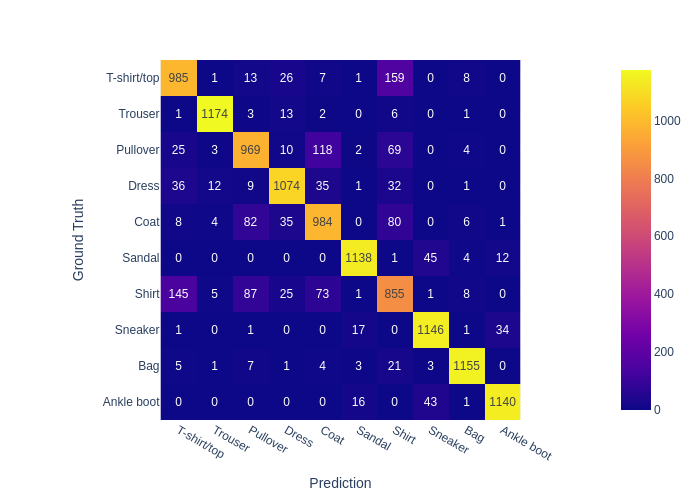

In [63]:
# Initialize confusion matrix with zeros
conf_matrix = np.zeros((len(class_names), len(class_names)), dtype=int)
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

# Fill the confusion matrix by counting predictions and plot it as a heatmap
for true_label, predicted_label in zip(test_df["label"], test_df["predicted_label"]):
    conf_matrix[class_to_idx[true_label], class_to_idx[predicted_label]] += 1

px.imshow(conf_matrix, labels=dict(x="Prediction", y="Ground Truth"), x=class_names, y=class_names, text_auto=True)

In [68]:
# Calculate accuracy from confusion matrix
accuracy_from_matrix = np.trace(conf_matrix) / np.sum(conf_matrix)
print(f"\nAccuracy calculated from confusion matrix: {accuracy_from_matrix:.3f}")

# Calculate per-class metrics from confusion matrix
per_class_metrics = []
print("\nPer-class metrics from confusion matrix:")
for i, class_name in enumerate(class_names):
    true_positives = conf_matrix[i, i]
    false_positives = np.sum(conf_matrix[:, i]) - true_positives
    false_negatives = np.sum(conf_matrix[i, :]) - true_positives
    true_negatives = np.trace(conf_matrix) - true_positives
    per_class_metrics.append({
        'class': class_name,
        'precision': true_positives / (true_positives + false_positives),
        'recall': true_positives / (true_positives + true_negatives),
    })

pd.DataFrame(per_class_metrics)


Accuracy calculated from confusion matrix: 0.885

Per-class metrics from confusion matrix:


,class,precision,recall
0,T-shirt/top,0.816750,0.092750
1,Trouser,0.978333,0.110546
2,Pullover,0.827498,0.091243
3,Dress,0.907095,0.101130
4,Coat,0.804579,0.092655
5,Sandal,0.965225,0.107156
6,Shirt,0.699101,0.080508
7,Sneaker,0.925687,0.107910
8,Bag,0.971405,0.108757
9,Ankle boot,0.960404,0.107345


In [69]:
grader.check("q3e")

q3e results: All test cases passed!

### Problem 3f: Analyze Prediction Confidence

In this section, we will analyze the model's prediction confidence to better understand its behavior. Specifically, we will identify examples where the model is uncertain or overly confident, and evaluate how these cases relate to the correctness of its predictions.

#### Objectives:
1. **Find the Image with the Lowest Confidence**:
    - Identify the image for which the model has the least confidence in its prediction.

2. **Analyze Low Confidence but Correct Predictions**:
    - Find examples where the model made the correct prediction but with low confidence.

3. **Analyze High Confidence but Incorrect Predictions**:
    - Identify examples where the model is highly confident but makes incorrect predictions.

**Task:** Let’s start by finding **the image with the lowest confidence**.

In [81]:
test_df.sort_values(by='confidence', ascending=True).iloc[0, :]

,6355
image,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 38.0, 88.0..."
label,Shirt
predicted_label,Shirt
correct,True
probs,"[9.479680703598957e-09, 0.02943516395857321, 1..."
confidence,0.328406


Image with lowest confidence:
             label predicted_label  confidence  correct
6355         Shirt           Shirt    0.328406     True
10309  T-shirt/top     T-shirt/top    0.373373     True
22369          Bag     T-shirt/top    0.410561    False


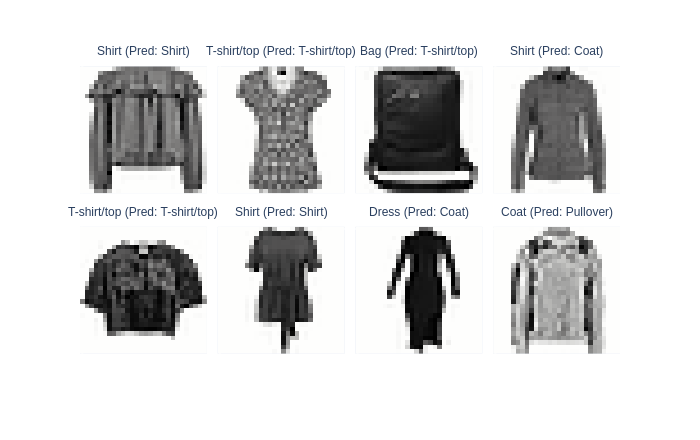

In [83]:
# TODO: Find the image with the lowest confidence by sorting the `confidence` column of `test_df`
least_confident = test_df.sort_values(by='confidence', ascending=True)
print("Image with lowest confidence:")
print(least_confident[['label', 'predicted_label', 'confidence', 'correct']][:3])

# Show image with lowest confidence and its predicted label
show_labels = [f"{label} (Pred: {predicted_label})" for label, predicted_label in zip(least_confident["label"].tolist(), least_confident["predicted_label"].tolist())]
fig = show_images(np.stack(least_confident["image"].tolist()), 8, ncols=4, labels=show_labels, reshape=True)
fig.show()

In [84]:
grader.check("q3f")

q3f results: All test cases passed!

### Problem 3g: Investigating Class Confusion for "Ankle boot"

**Task:**
Visualize Low-Confidence Correct Predictions: Display 10 test images where the true label is "Ankle boot," the prediction is correct, but confidence is lowest.

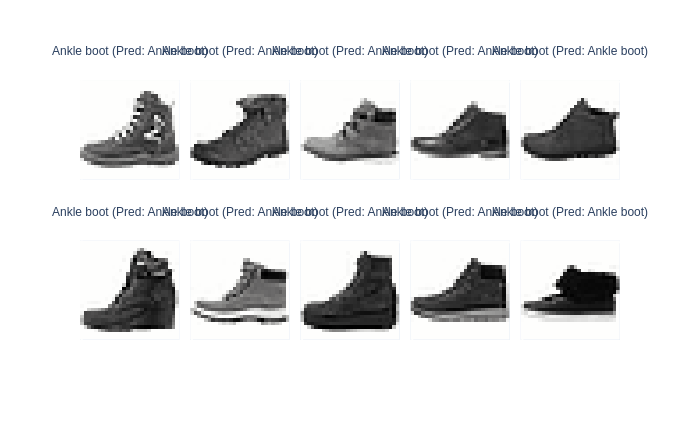

In [101]:
# TODO: Visualize 10 images from the `test_set` whose true label is `Ankle boot` that the model correctly classified but with low confidence
test_df_boot = test_df[(test_df['label'] == 'Ankle boot') & (test_df['correct'] == True)]

# Find low confidence correct predictions (uncertain but right)
low_conf_correct =  test_df_boot.sort_values(by='confidence', ascending=True)

# Visualize low confidence correct predictions
show_labels = [f"{label} (Pred: {predicted_label})" for label, predicted_label in zip(low_conf_correct["label"].tolist(), low_conf_correct["predicted_label"].tolist())]
fig = show_images(np.stack(low_conf_correct["image"].tolist()), 10, ncols=5, labels=show_labels, reshape=True)
fig.show()

In [102]:
grader.check("q3g")

q3g results: All test cases passed!

### Problem 3h: Reasons for Low Confidence in the "Ankle boot" Class

**Task:** Analyze visual patterns in low-confidence images for the "Ankle boot" class. What is a potential reasons for the model to be so unconfident in these classifications?

_The dataset has visually similar objects to ankle bots, such as sneakers, and the classifier can be affected by them._

<!-- END QUESTION -->

### Problem 3i: Investigating Class Confusion for "Trouser"

Now let's look at cases where the model is confidently incorrect.

**Task:** For the `Trouser` class, visualize the 10 images from the test set which are incorrectly classified as `Dress` but have the highest confience and answer the question below.

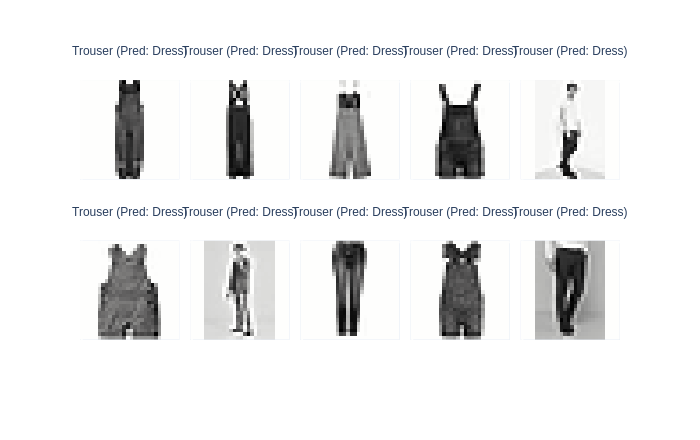

In [103]:
# TODO: Visualize 10 images from the `test_set` whose true label is `Trouser` that the model incorrectly classified as `Dress` with high confidence
test_df_trouser = test_df[(test_df['label'] == 'Trouser') & (test_df['predicted_label'] == 'Dress')]

# Find high confidence incorrect predictions (confident but() wrong)
high_conf_incorrect = test_df_trouser.sort_values(by='confidence', ascending=False)

# Visualize high confidence incorrect predictions
show_labels = [f"{label} (Pred: {predicted_label})" for label, predicted_label in zip(high_conf_incorrect["label"].tolist(), high_conf_incorrect["predicted_label"].tolist())]
fig = show_images(np.stack(high_conf_incorrect["image"].tolist()), 10, ncols=5, labels=show_labels, reshape=True)
fig.show()

In [104]:
grader.check("q3i")

q3i results: All test cases passed!

### Problem 3j: Reasons for High Confidence in the "Trouser" Class

**Task:** What are some potential reasons for the model to be so confident in its classifications of some of these examples?

_Images that are incorrectly predicted as trouser actually has trousers like articles_

## Submission

**Please compress this notebook together with your written homework solutions into a single ZIP file and upload it to LearnHub.**

**Acknowledgement**: This assignment was adapted from the materials of UC Berkeley's CS189 course.